## Import libraries, units dataframe and configure device

In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
from scipy.sparse import coo_matrix

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('tables/units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  firing_rate  response_mag  sparsity  pyr  sst  ...  \
0           0           0     2.347611     -0.165334 -0.110431    1    0  ...   
1           0           0     0.608558     -0.119121 -0.137173    1    0  ...   
2           0           0     0.932567      0.146078  0.053006    1    0  ...   
3           0           4    11.398961     -0.184356 -0.109291    1    0  ...   
4           0           0     8.338130      0.441873 -0.053603    0    0  ...   

   burstIndex_Royer2012  burstIndex_Mizuseki2012  num_co

## Define session obj


In [2]:
session_id  = 1130113579 # 1087720624

output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')
session_obj = ps(session_id, df, output_dir)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
input_size = len(session_obj.units)
num_epochs = 15 # 
batch_size = 32

# hyperparameters
hidden_size = 50 # 
num_layers = 1
seqlength = 750
attr_dur = 720 

# define output directory for saved models
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
output_dir_plots = output_dir_models / 'plots'
os.makedirs(output_dir_plots, exist_ok=True)

## Get spikes_obj and lfp_obj

In [3]:
bin_size=0.004
sr = 1/bin_size
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
spikes_obj.minmax()

lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj.truncate(seqlength)
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

locs = spikes_obj.units['structure_acronym'].values
areas = np.unique(locs)

In [56]:
ctx = [area for area in areas if 'VIS' in area]
ctx_no_visp = [area for area in areas if 'VIS' in area and 'VISp' not in area]
hpc = [area for area in areas if 'CA' in area or 'DG' in area or 'SUB' in area
       or 'HPF' in area or 'ProS' in area or 'POST' in area]
subcortical = [area for area in areas if area not in ctx and area not in hpc]

sum_ctx = spikes_obj.units['structure_acronym'].isin(ctx).sum()
sum_ctx_no_visp = spikes_obj.units['structure_acronym'].isin(ctx_no_visp).sum()
sum_hpc = spikes_obj.units['structure_acronym'].isin(hpc).sum()
sum_subcortical = spikes_obj.units['structure_acronym'].isin(subcortical).sum()
print(f'Number of units in cortex: {sum_ctx}')
print(f'Number of units in cortex excluding VISp: {sum_ctx_no_visp}')
print(f'Number of units in hippocampus: {sum_hpc}')
print(f'Number of units in subcortical areas: {sum_subcortical}')

rate_ctx = session_obj.units.firing_rate[session_obj.units['structure_acronym'].isin(ctx)].mean()
rate_ctx_no_visp = session_obj.units.firing_rate[session_obj.units['structure_acronym'].isin(ctx_no_visp)].mean()
rate_hpc = session_obj.units.firing_rate[session_obj.units['structure_acronym'].isin(hpc)].mean()
rate_subcortical = session_obj.units.firing_rate[session_obj.units['structure_acronym'].isin(subcortical)].mean()
print(f'Mean firing rate in cortex: {rate_ctx:.2f} Hz')
print(f'Mean firing rate in cortex excluding VISp: {rate_ctx_no_visp:.2f} Hz')
print(f'Mean firing rate in hippocampus: {rate_hpc:.2f} Hz')
print(f'Mean firing rate in subcortical areas: {rate_subcortical:.2f} Hz')

Number of units in cortex: 302
Number of units in cortex excluding VISp: 209
Number of units in hippocampus: 197
Number of units in subcortical areas: 323
Mean firing rate in cortex: 5.91 Hz
Mean firing rate in cortex excluding VISp: 6.28 Hz
Mean firing rate in hippocampus: 11.18 Hz
Mean firing rate in subcortical areas: 13.14 Hz


In [ ]:
chani = 5 
bandi = 0 
                     
X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

Total parameters: 148,467
LSTM  train loss: 0.2073
LSTM  test loss: 0.2255


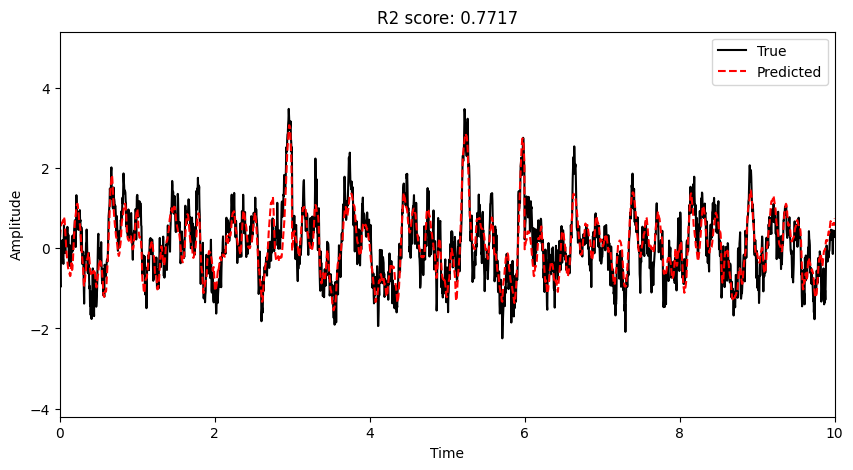

In [10]:
# input_size = sum(mask)
input_size = len(session_obj.units)

lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

total_params = sum(p.numel() for p in lstm_model.model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
# plt.savefig(output_dir_plots / 'LSTM_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
# ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
# ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
# ax.set_xlabel('Time')
# ax.set_ylabel('Amplitude')
# ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
# ax.legend()
# # save figure in pdf format
# plt.savefig(output_dir_plots / 'LSTM_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.show() 

In [ ]:
from spectral_analysis import bandpass_filter, calculate_band_r2
r2_res_full_model = calculate_band_r2(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy(),bands[:-2], sr)
print(f'R2 score full model:\n{r2_res_full_model}')

mask_ctx = spikes_obj.units['structure_acronym'].isin(ctx)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat[:,mask_ctx], lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)
train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)
lstm_model = models.process_model(models.LSTMnet(sum(mask_ctx), hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])
r2_res_ctx = calculate_band_r2(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy(),bands[:-2], sr)

print(f'R2 score cortex:\n{r2_res_ctx}')

mask_ctx_no_visp = spikes_obj.units['structure_acronym'].isin(ctx_no_visp)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat[:,mask_ctx_no_visp], lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)
train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)
lstm_model = models.process_model(models.LSTMnet(sum(mask_ctx_no_visp), hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])
mask_ctx_no_visp = calculate_band_r2(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy(),bands[:-2], sr)

print(f'R2 score cortex excluding VISp:\n{mask_ctx_no_visp}')

mask_hpc = spikes_obj.units['structure_acronym'].isin(hpc)
X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat[:,mask_hpc], lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)
train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)
lstm_model = models.process_model(models.LSTMnet(sum(mask_hpc), hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,    
                                        test_dataloader , num_epochs)
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])
r2_res_hpc = calculate_band_r2(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy(),bands[:-2], sr)
print(f'R2 score HPC:\n{r2_res_hpc}')


mask_subcortical = spikes_obj.units['structure_acronym'].isin(subcortical)
X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat[:,mask_subcortical], lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)
train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)
lstm_model = models.process_model(models.LSTMnet(sum(mask_subcortical), hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])
r2_res_subcortical = calculate_band_r2(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy(),bands[:-2], sr)
print(f'R2 score subcortical:\n{r2_res_subcortical}')


R2 score full model:
0.5-4 Hz     0.808181
4-8 Hz       0.348740
8-12 Hz      0.064455
12-25 Hz     0.001166
25-50 Hz    -0.008854
50-100 Hz   -0.001286
dtype: float64
R2 score cortex:
0.5-4 Hz     0.879396
4-8 Hz       0.525502
8-12 Hz      0.136342
12-25 Hz     0.029934
25-50 Hz    -0.001812
50-100 Hz   -0.007906
dtype: float64
R2 score cortex excluding VISp:
0.5-4 Hz     0.838363
4-8 Hz       0.378543
8-12 Hz      0.076777
12-25 Hz     0.037530
25-50 Hz    -0.007906
50-100 Hz   -0.004824
dtype: float64
R2 score HPC:
0.5-4 Hz     0.271008
4-8 Hz       0.405527
8-12 Hz      0.084233
12-25 Hz     0.022244
25-50 Hz    -0.022797
50-100 Hz   -0.007830
dtype: float64
R2 score subcortical:
0.5-4 Hz     0.808181
4-8 Hz       0.348740
8-12 Hz      0.064455
12-25 Hz     0.001166
25-50 Hz    -0.008854
50-100 Hz   -0.001286
dtype: float64


In [51]:
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)
timestamps = spikes_obj.timestamps[:int(attr_dur/bin_size)]
stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st[((stim_st - np.abs(t[0])) > timestamps[0]) & ((stim_st + np.abs(t[-1])) < timestamps[-1])]
stim_st = stim_st.values

# calculate the PSTHs of all neurons
psth = np.zeros((spikes_obj.spkMat.shape[1], 188))
for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(t[0])  )))
    psth += spikes_obj.spkMat[start:start+len(t),:].T
psth /= len(stim_st)

# for each cluster, calculate the mean attribution across all channels and bands            
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
for i in range(1,6):
    cluster_id[i] = list(df.unit_id[df['cluster_id'] == i])

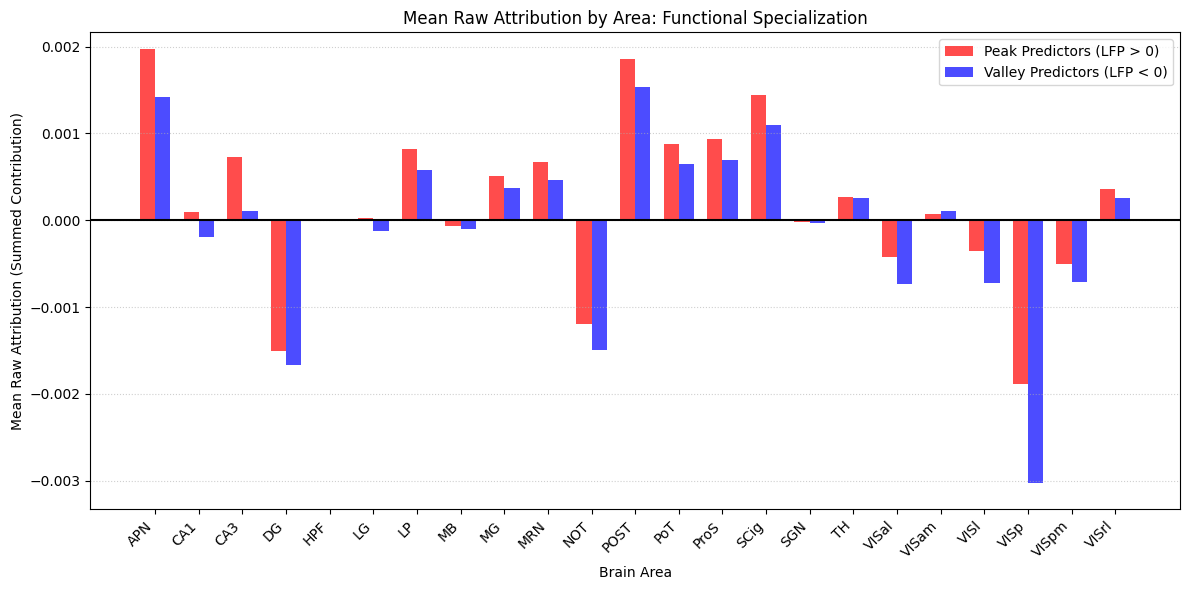

In [77]:
bandi = 0
chani = 16

sparse_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npz')
attrs = coo_matrix((sparse_attr['data'], (sparse_attr['row'], sparse_attr['col'])), shape=sparse_attr['shape']).toarray()
total_attr = np.nansum(np.abs(attrs), axis=1, keepdims=True)
attrs = attrs / (total_attr + 1e-10)

N_regions = len(areas)
region_names = list(areas)

target_lfp = lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0]
# Create boolean masks for LFP signs
peak_mask = (target_lfp > 0)
valley_mask = (target_lfp < 0)

# Initialize arrays to store the results
peak_mean_attribution = np.zeros(N_regions)
valley_mean_attribution = np.zeros(N_regions)

# --- 2. Calculate Mean Raw Attribution Per Area Per LFP Sign ---

for r_idx, region in enumerate(region_names):
    # Mask for all neurons belonging to the current region
    area_neuron_mask = (locs == region)
    
    # 1. Calculate the raw attribution time series for this area (summed across neurons)
    # Result is a 1D array (N_timepoints,) showing the total raw attribution for the region at each moment
    total_raw_attribution_time_series = np.sum(attrs[:, area_neuron_mask], axis=1) / np.sum(area_neuron_mask)
    
    # 2. Segment and average the total raw attribution based on LFP sign
    
    # Mean raw attribution during LFP Peaks (target LFP > 0)
    if np.any(peak_mask):
        peak_mean_attribution[r_idx] = np.mean(total_raw_attribution_time_series[peak_mask])
    
    # Mean raw attribution during LFP Valleys (target LFP < 0)
    if np.any(valley_mask):
        valley_mean_attribution[r_idx] = np.mean(total_raw_attribution_time_series[valley_mask])


# --- 3. Visualization: Comparison Bar Chart ---

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(N_regions)     # Label locations (0, 1, 2, ...)
width = 0.35                 # Width of the individual bars

# Calculate Y-limits for symmetry around zero
y_min = min(peak_mean_attribution.min(), valley_mean_attribution.min()) * 1.1
y_max = max(peak_mean_attribution.max(), valley_mean_attribution.max()) * 1.1

# 1. Plot Peak Predictors (LFP > 0): Shifted to the left
rects1 = ax.bar(x - width/2, peak_mean_attribution, width, 
                label='Peak Predictors (LFP > 0)', color='r', alpha=0.7)

# 2. Plot Valley Predictors (LFP < 0): Shifted to the right
rects2 = ax.bar(x + width/2, valley_mean_attribution, width, 
                label='Valley Predictors (LFP < 0)', color='b', alpha=0.7)

# Add Labels and Cosmetics
ax.set_title('Mean Raw Attribution by Area: Functional Specialization')
ax.set_ylabel('Mean Raw Attribution (Summed Contribution)')
ax.set_xlabel('Brain Area')
ax.set_xticks(x)
ax.set_xticklabels(region_names, rotation=45, ha='right')
ax.axhline(0, color='k', linewidth=1.5) # Zero line for reference
ax.legend(loc='upper right')

# Set symmetrical Y-axis limits
ax.set_ylim(y_min, y_max)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Compute rank matrix of a chosen channel

In [78]:
bandi = 0
chani = 16

sparse_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npz')
attrs = coo_matrix((sparse_attr['data'], (sparse_attr['row'], sparse_attr['col'])), shape=sparse_attr['shape']).toarray()
total_attr = np.nansum(np.abs(attrs), axis=1, keepdims=True)
attrs = attrs / (total_attr + 1e-10) 
abs_attrs = np.abs(attrs)

rank_matrix = np.zeros_like(attrs)

n_neurons = attrs.shape[1]
n_timepoints = attrs.shape[0]

for ti in range(n_timepoints):
    # Get absolute values for this time point
    abs_values_t = abs_attrs[ti, :]
    
    # 1. Get indices that would sort the absolute values in ASCENDING order
    # (Least influential neuron's index is first)
    sorted_indices_ascending = np.argsort(abs_values_t)
    
    # 2. Assign ranks based on the ascending order. 
    # The last element in the ascending sort is the most influential (Rank 1).
    # The first element is the least influential (Rank n_neurons).
    
    # Ranks range from 1 to n_neurons.
    # The array np.arange(n_neurons, 0, -1) creates ranks [n, n-1, ..., 1]
    ranks_descending = np.arange(n_neurons, 0, -1)
    
    # The assignment below is the critical step:
    # It assigns the rank (from ranks_descending) to the neuron index 
    # specified by sorted_indices_ascending.
    rank_matrix[ti, sorted_indices_ascending] = ranks_descending

In [79]:
K = 40
n_timepoints = rank_matrix.shape[0]
jaccard_scores = np.zeros(n_timepoints - 1)
jaccard_scores_regional = np.zeros(n_timepoints - 1)

# Iterate from the first time point (t=0) up to the second-to-last time point
for ti in range(n_timepoints - 1):
    # A. Get the set of influential neurons at time t (S_t)
    # The rank_matrix holds ranks 1 to 623. We want indices where rank <= K.
    # Convert to a set for efficient intersection/union operations.
    indices_t = np.where(rank_matrix[ti, :] <= K)[0]
    regions_t_array = locs[indices_t]
    
    S_t = set(indices_t)
    C_t = set(regions_t_array)
    
    # B. Get the set of influential neurons at time t+1 (S_t+1)
    indices_t_plus_1 = np.where(rank_matrix[ti+1, :] <= K)[0]
    regions_t_plus_1_array = locs[indices_t_plus_1]
    
    S_t_plus_1 = set(indices_t_plus_1)
    C_t_plus_1 = set(regions_t_plus_1_array)
    
    # C. Calculate Intersection and Union
    intersection = len(S_t.intersection(S_t_plus_1))
    union = len(S_t.union(S_t_plus_1))
    
    intersection_regions = len(C_t.intersection(C_t_plus_1))
    union_regions = len(C_t.union(C_t_plus_1))   

    # D. Calculate Jaccard Similarity (Intersection / Union)
    # Handle the unlikely case of a zero union (though rank_matrix ensures K elements)
    if union > 0:
        jaccard_scores[ti] = intersection / union
    else:
        jaccard_scores[ti] = 0
        
    if union_regions > 0:
        jaccard_scores_regional[ti] = intersection_regions / union_regions
    else:
        jaccard_scores_regional[ti] = 0  

visusalizing results


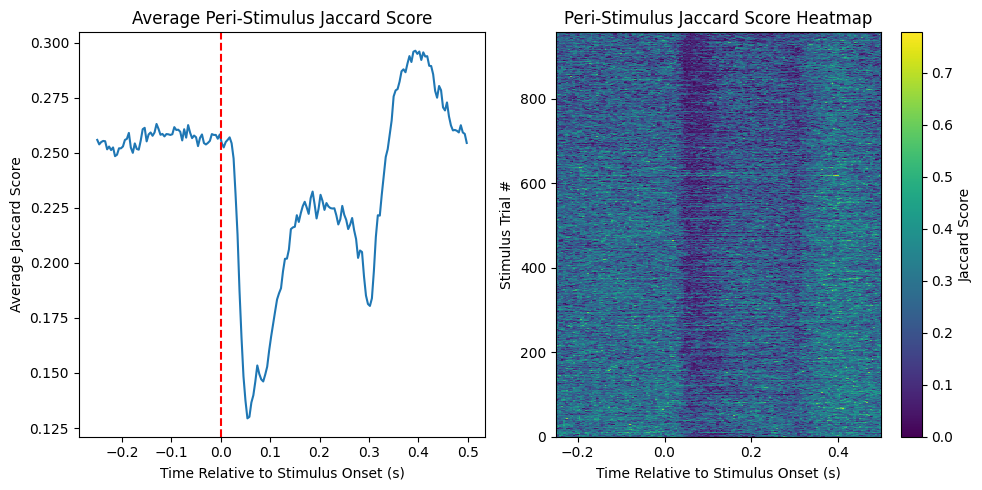

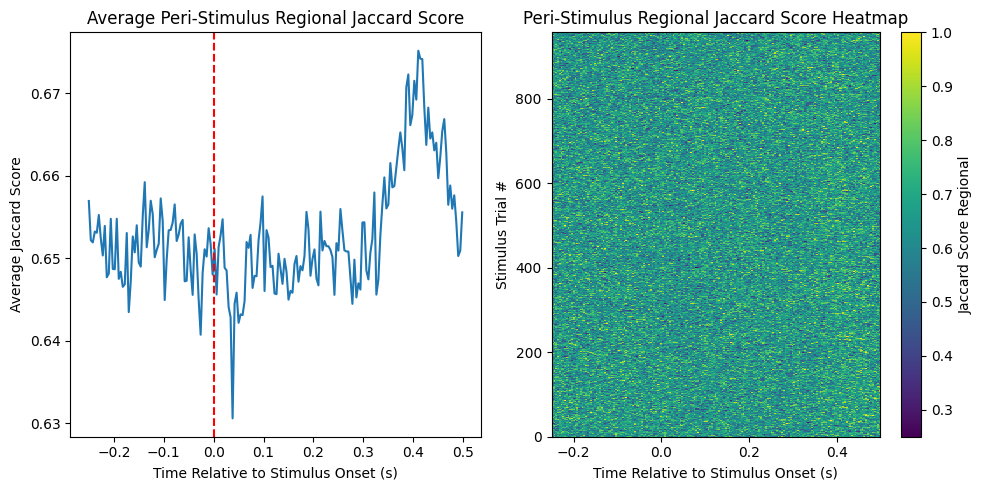

In [80]:
# calculate stimulus triggered Jaccard score
n_bins_in_snippet = len(t)

# Initialize the storage matrix: (n_trials, n_bins)
# The second dimension is the number of time bins in your window.
jaccard_snippets = np.zeros((len(stim_st), n_bins_in_snippet))
jaccard_snippets_regions = np.zeros((len(stim_st), n_bins_in_snippet))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    jaccard_snippets[i, :] = jaccard_scores[start_idx : start_idx + n_bins_in_snippet]
    jaccard_snippets_regions[i, :] = jaccard_scores_regional[start_idx : start_idx + n_bins_in_snippet]

# --- Visualization ---
print('visusalizing results')

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets, axis=0))
ax[0].set_title('Average Peri-Stimulus Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets_regions, axis=0))
ax[0].set_title('Average Peri-Stimulus Regional Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets_regions, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Regional Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score Regional')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()


In [81]:
areas = np.unique(locs)
N_regions = len(areas)
N_bins_in_snippet = len(t) 
N_trials = len(stim_st)

InverseRank_Matrix = 1/rank_matrix
dominance_scores_3D = np.zeros((N_trials, N_regions, N_bins_in_snippet))

region_masks = {}
for region in areas:
    # Mask is True where the neuron belongs to the current region
    region_masks[region] = (locs == region)

# Convert region_list to an ordered index for the 3D array
region_names = list(areas)

# Iterate through each stimulus trial
for i in range(N_trials):
    # 1. Determine the start index in the full InverseRank matrix
    start_time_sec = stim_st[i] + time_win[0]
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # 2. Extract the snippet (2D array: N_bins_in_snippet x N_neurons)
    snippet = InverseRank_Matrix[start_idx : start_idx + N_bins_in_snippet, :]
    
    # 3. Calculate Dominance Score for each region in the snippet
    for r_idx, region in enumerate(region_names):
        mask = region_masks[region]
        
        # NumPy magic: Sum the Inverse Ranks only for neurons where the mask is True.
        # This gives a 1D array of scores (one score per time bin in the snippet).
        dominance_score_time_series = np.sum(snippet[:, mask], axis=1) / np.sum(mask)
        
        # 4. Store the result in the 3D array
        dominance_scores_3D[i, r_idx, :] = dominance_score_time_series
        

average_dominance_scores = np.mean(dominance_scores_3D, axis=0) 
err_dominance_scores     = np.std(dominance_scores_3D, axis=0) / np.sqrt(N_trials)

total_influence_time_series = np.sum(average_dominance_scores, axis=0)

# Reshape total_influence_time_series for broadcasting: (1, N_bins_in_snippet)
total_influence_reshaped = total_influence_time_series[np.newaxis, :]

# 2. Calculate Proportional Influence
# This divides the mean score of EACH area by the total mean score across all areas at that time bin.
# Shape: (N_regions, N_bins_in_snippet)
proportional_influence = average_dominance_scores / total_influence_reshaped

# Handle division by zero where total influence is zero (set proportion to zero)
proportional_influence = np.nan_to_num(proportional_influence, nan=0.0)

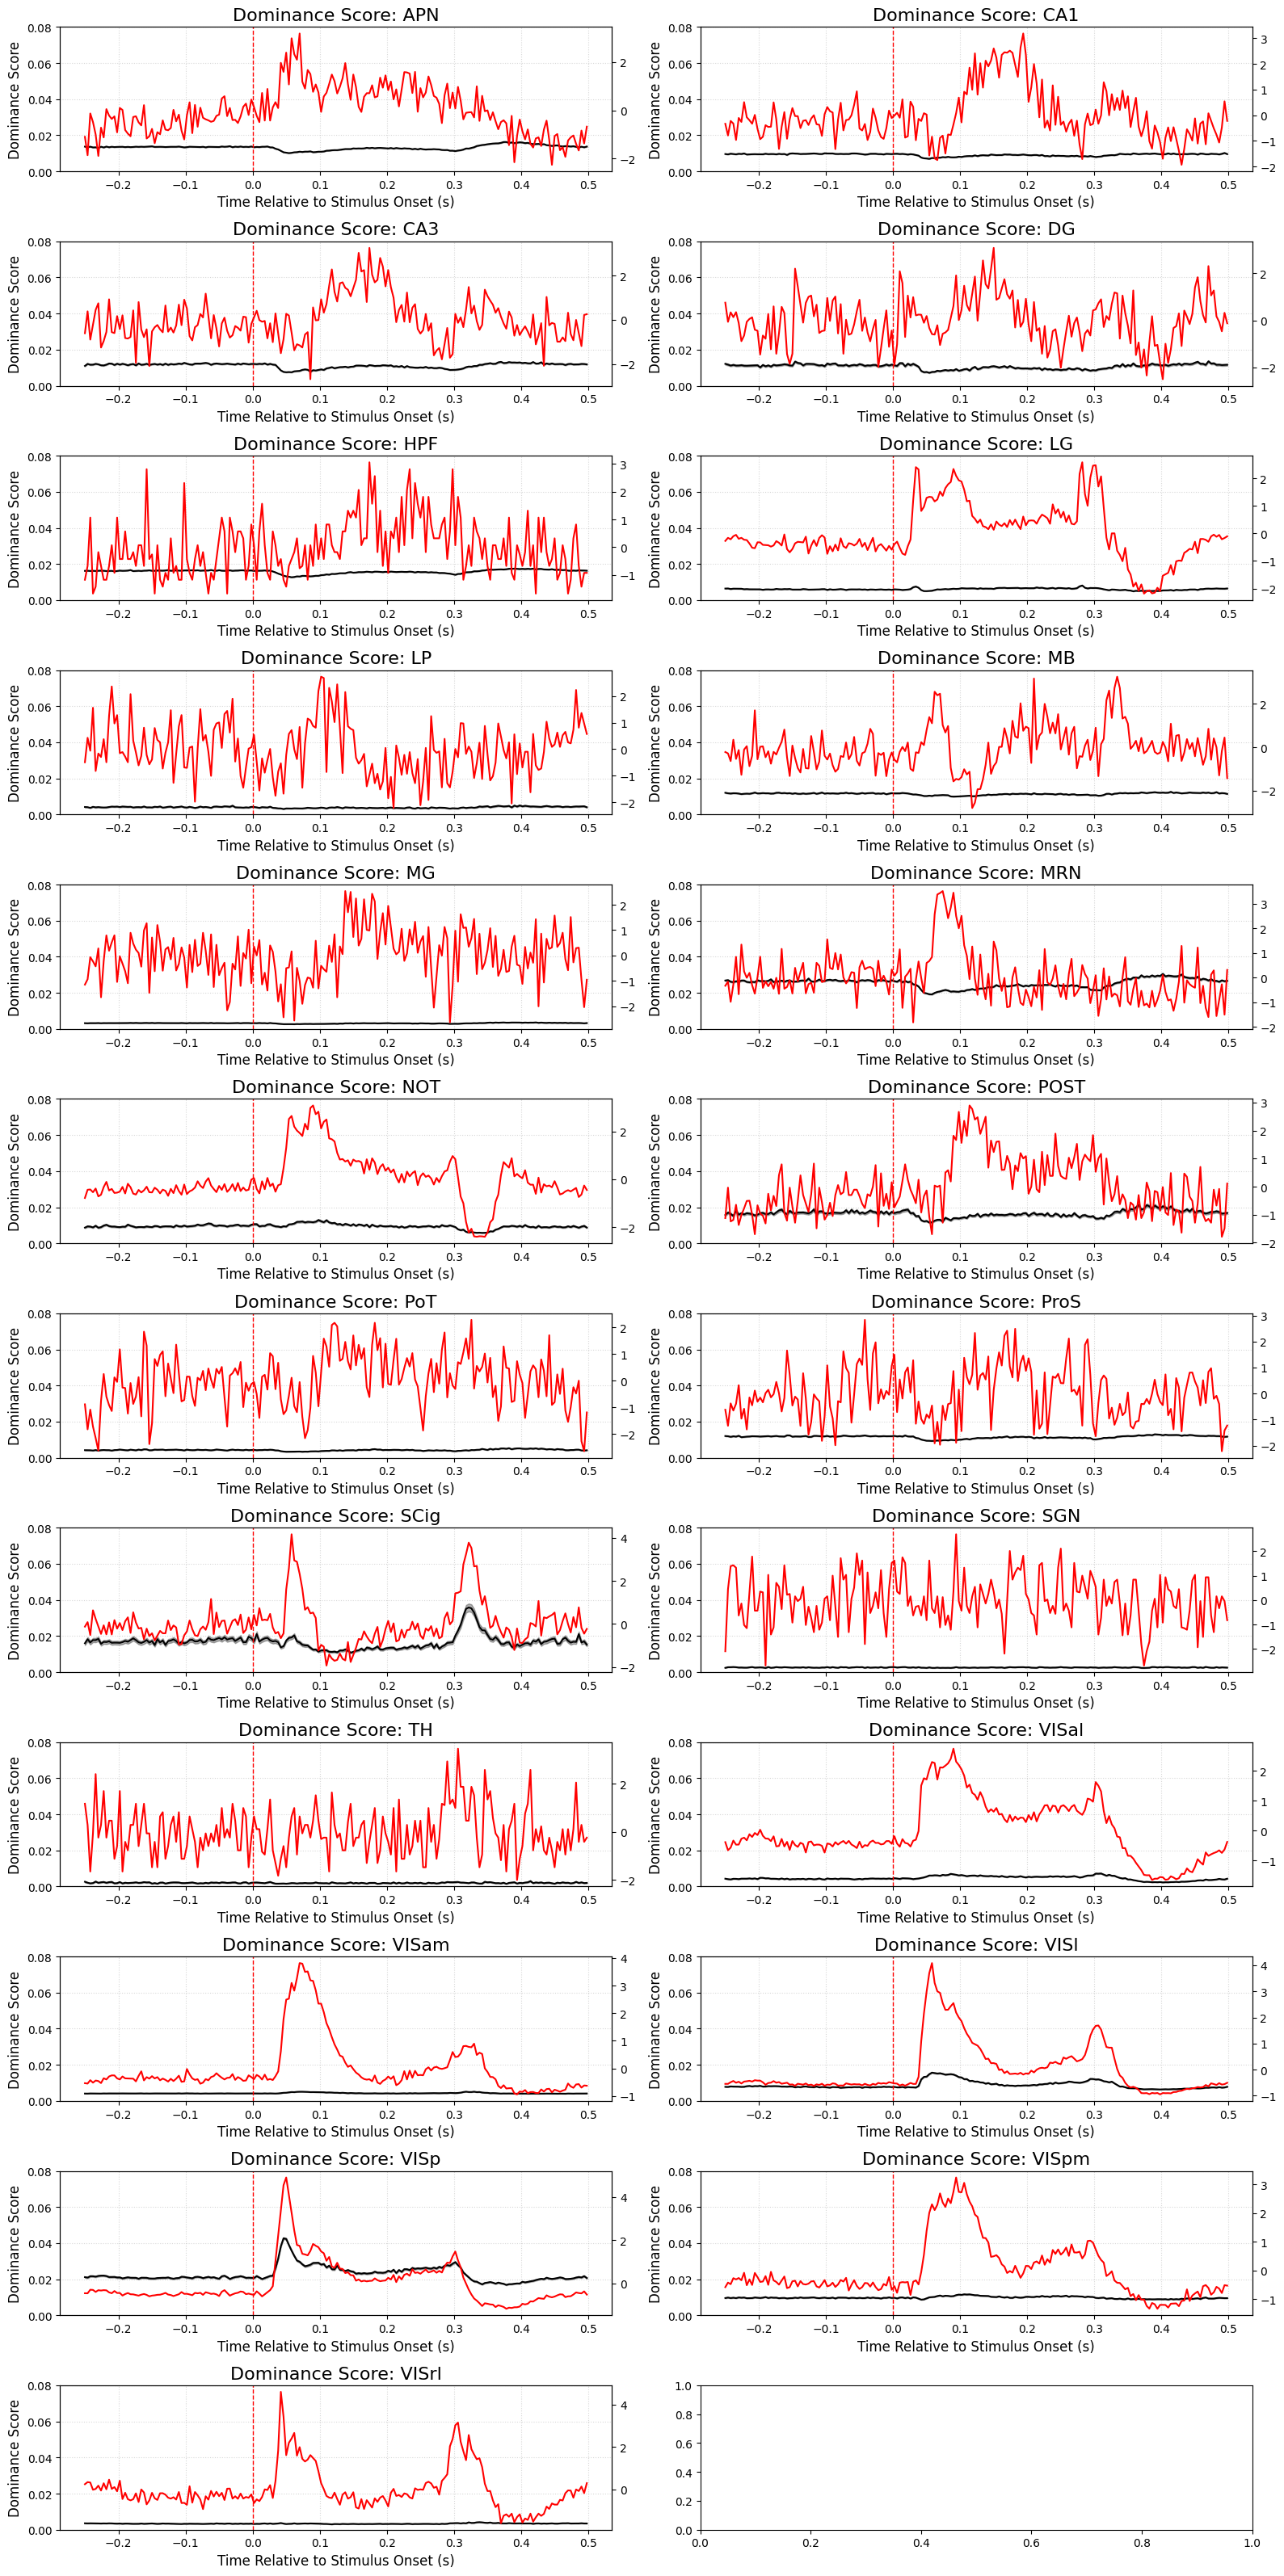

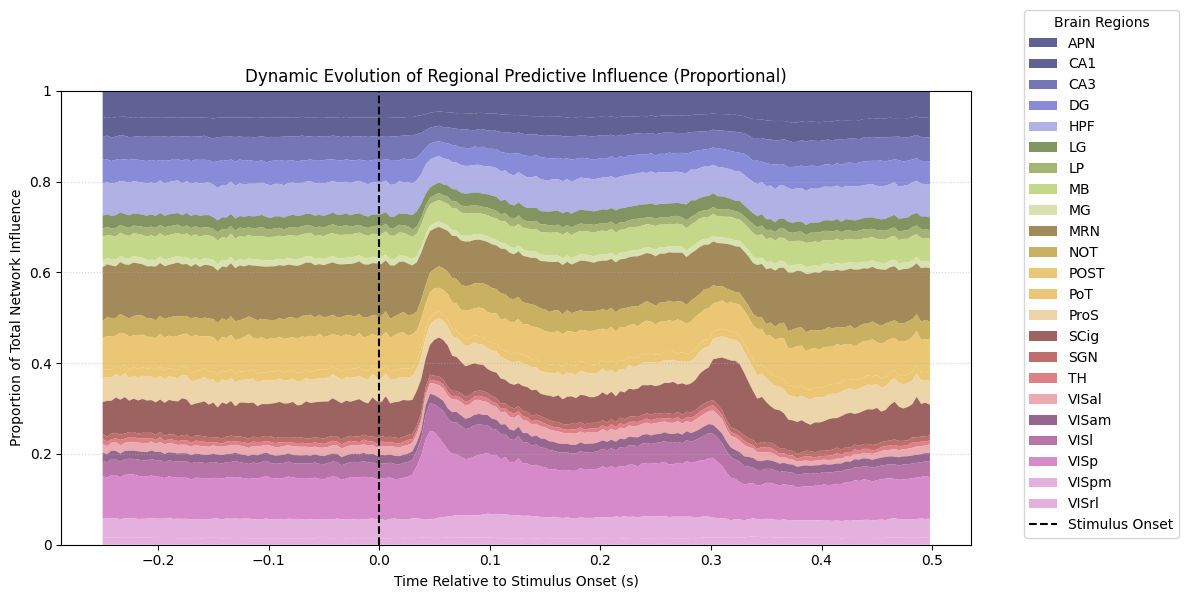

In [82]:
import matplotlib.cm as cm

fig, ax = plt.subplots(int(np.ceil(len(areas)/2)) ,2,figsize=(16,32))
for areai in range(len(areas)):
    ax.flat[areai].plot(t, average_dominance_scores[areai,:], 'k')
    ax.flat[areai].fill_between(t, 
                            average_dominance_scores[areai,:] - err_dominance_scores[areai,:], 
                            average_dominance_scores[areai,:] + err_dominance_scores[areai,:], 
                            color='k', 
                            alpha=0.3,
                            label='SEM')
    # add the psth of that area on a twin ax
    ax2 = ax.flat[areai].twinx()
    ax2.plot(t, zscore(np.mean(psth[locs == areas[areai],:], axis=0)), 'r')
    
    ax.flat[areai].axvline(0, color='r', linestyle='--', linewidth=1)
    ax.flat[areai].set_title(f'Dominance Score: {region_names[areai]}', fontsize=16)
    ax.flat[areai].set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
    ax.flat[areai].set_ylabel('Dominance Score', fontsize=12)
    ax.flat[areai].grid(True, linestyle=':', alpha=0.5)
    ax.flat[areai].set_ylim(0, 0.08)
    
plt.tight_layout()
plt.show()

colors = cm.get_cmap('tab20b', N_regions)(np.arange(N_regions))

fig, ax = plt.subplots(figsize=(12, 6))
# Use Matplotlib's 'stackplot' for the stacked area chart
ax.stackplot(t, proportional_influence, 
             labels=region_names,
             colors=colors, # Apply the generated distinct colors
             alpha=0.8)


# Add stimulus onset
ax.axvline(0, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')

# Add Labels and Title
ax.set_title('Dynamic Evolution of Regional Predictive Influence (Proportional)')
ax.set_xlabel('Time Relative to Stimulus Onset (s)')
ax.set_ylabel('Proportion of Total Network Influence')
ax.set_ylim(0, 1) # Proportions must sum to 1
ax.legend(loc='lower left', bbox_to_anchor=(1.05, 0), title='Brain Regions')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.invert_yaxis()
ax.set_yticklabels([1,.8,.6,.4,.2,0])
plt.tight_layout()
plt.show()

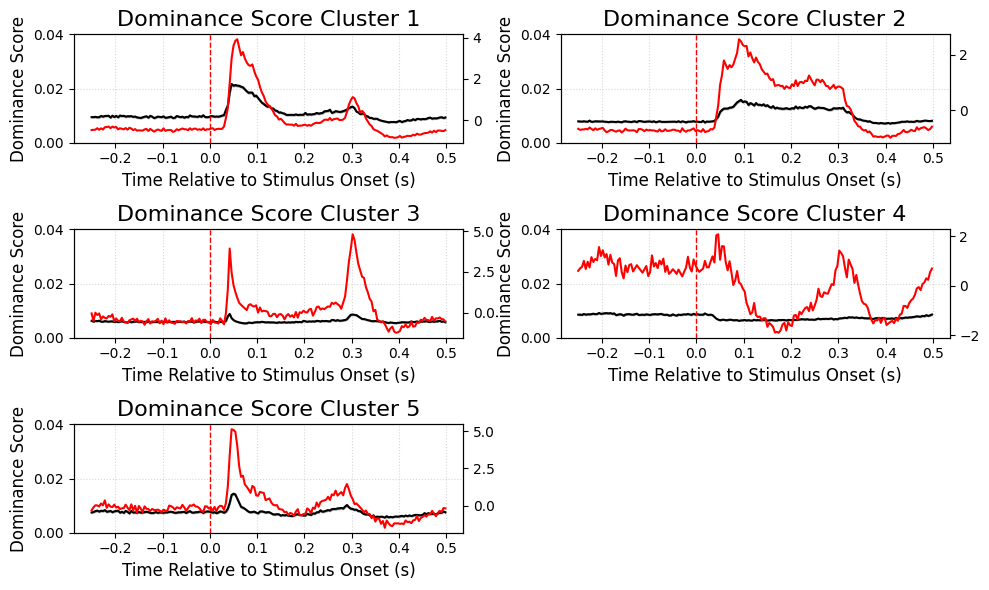

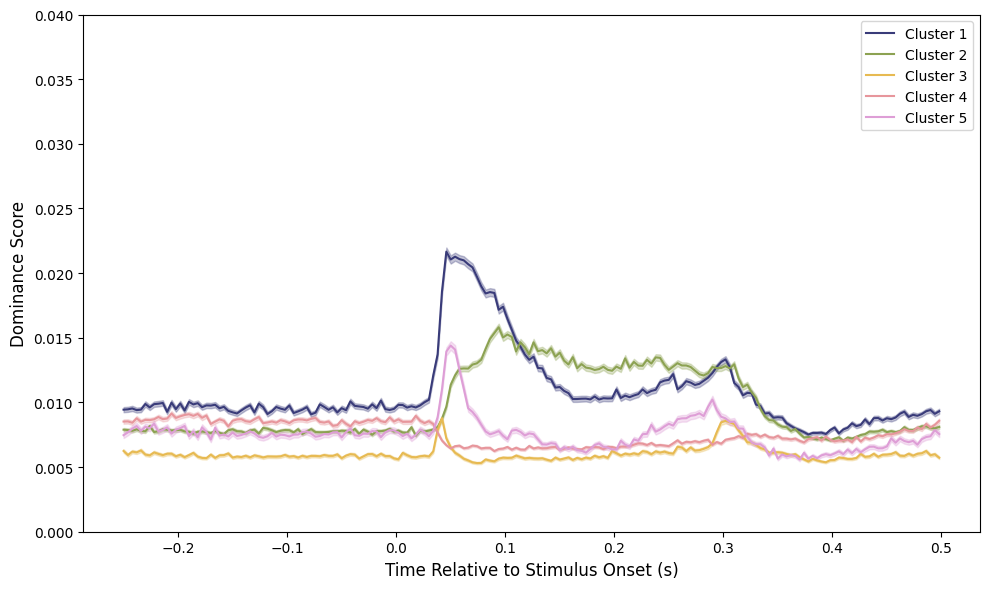

In [83]:
dominance_scores_clusters_3D = np.zeros((N_trials, 5, N_bins_in_snippet))

# Iterate through each stimulus trial
for i in range(N_trials):
    # 1. Determine the start index in the full InverseRank matrix
    start_time_sec = stim_st[i] + time_win[0]
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # 2. Extract the snippet (2D array: N_bins_in_snippet x N_neurons)
    snippet = InverseRank_Matrix[start_idx : start_idx + N_bins_in_snippet, :]
    
    # 3. Calculate Dominance Score for each region in the snippet
    for clusteri in range(1,6):
        mask = session_obj.units.index.isin(cluster_id[clusteri])
        
        # NumPy magic: Sum the Inverse Ranks only for neurons where the mask is True.
        # This gives a 1D array of scores (one score per time bin in the snippet).
        dominance_score_time_series = np.sum(snippet[:, mask], axis=1) / np.sum(mask)
        
        # 4. Store the result in the 3D array
        dominance_scores_clusters_3D[i, clusteri-1, :] = dominance_score_time_series
        

average_dominance_scores_clusters = np.mean(dominance_scores_clusters_3D, axis=0) 
err_dominance_scores_clusters     = np.std(dominance_scores_clusters_3D, axis=0) / np.sqrt(N_trials)

total_influence_time_series_clusters = np.sum(average_dominance_scores_clusters, axis=0)

# Reshape total_influence_time_series for broadcasting: (1, N_bins_in_snippet)
total_influence_clusters_reshaped = total_influence_time_series_clusters[np.newaxis, :]

# 2. Calculate Proportional Influence
# This divides the mean score of EACH area by the total mean score across all areas at that time bin.
# Shape: (N_regions, N_bins_in_snippet)
proportional_influence_clusters = average_dominance_scores_clusters / total_influence_clusters_reshaped

# Handle division by zero where total influence is zero (set proportion to zero)
proportional_influence_clusters = np.nan_to_num(proportional_influence_clusters, nan=0.0)

fig, ax = plt.subplots(3 ,2,figsize=(10,6))
for clusteri in range(5):
    ax.flat[clusteri].plot(t, average_dominance_scores_clusters[clusteri,:], 'k')
    ax.flat[clusteri].fill_between(t, 
                            average_dominance_scores_clusters[clusteri,:] - err_dominance_scores_clusters[clusteri,:], 
                            average_dominance_scores_clusters[clusteri,:] + err_dominance_scores_clusters[clusteri,:], 
                            color='k', 
                            alpha=0.3,
                            label='SEM')
    # add the psth of that area on a twin ax
    ax2 = ax.flat[clusteri].twinx()
    mask = session_obj.units.index.isin(cluster_id[clusteri+1])
    ax2.plot(t, zscore(np.mean(psth[mask,:], axis=0)), 'r')
    
    ax.flat[clusteri].axvline(0, color='r', linestyle='--', linewidth=1)
    ax.flat[clusteri].set_title(f'Dominance Score Cluster {clusteri+1}', fontsize=16)
    ax.flat[clusteri].set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
    ax.flat[clusteri].set_ylabel('Dominance Score', fontsize=12)
    ax.flat[clusteri].grid(True, linestyle=':', alpha=0.5)
    ax.flat[clusteri].set_ylim(0, 0.04)

fig.delaxes(ax.flat[-1])    
plt.tight_layout()
plt.show()

colors = cm.get_cmap('tab20b', 5)(np.arange(5))

# all cluisters in one plot
fig, ax = plt.subplots(1 ,1,figsize=(10,6))
for clusteri in range(5):
    ax.plot(t, average_dominance_scores_clusters[clusteri,:], label = f'Cluster {clusteri+1}', color=colors[clusteri,:])
    ax.fill_between(t, 
                        average_dominance_scores_clusters[clusteri,:] - err_dominance_scores_clusters[clusteri,:], 
                        average_dominance_scores_clusters[clusteri,:] + err_dominance_scores_clusters[clusteri,:], 
                        color=colors[clusteri,:], 
                        alpha=0.3)
ax.set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
ax.set_ylabel('Dominance Score', fontsize=12)
ax.set_ylim(0, 0.04)
plt.legend()
plt.tight_layout()
plt.show()

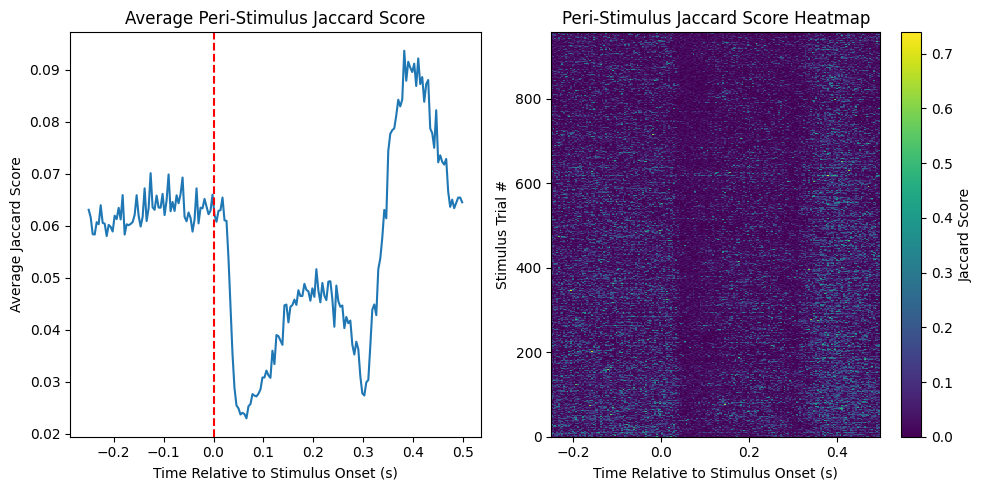

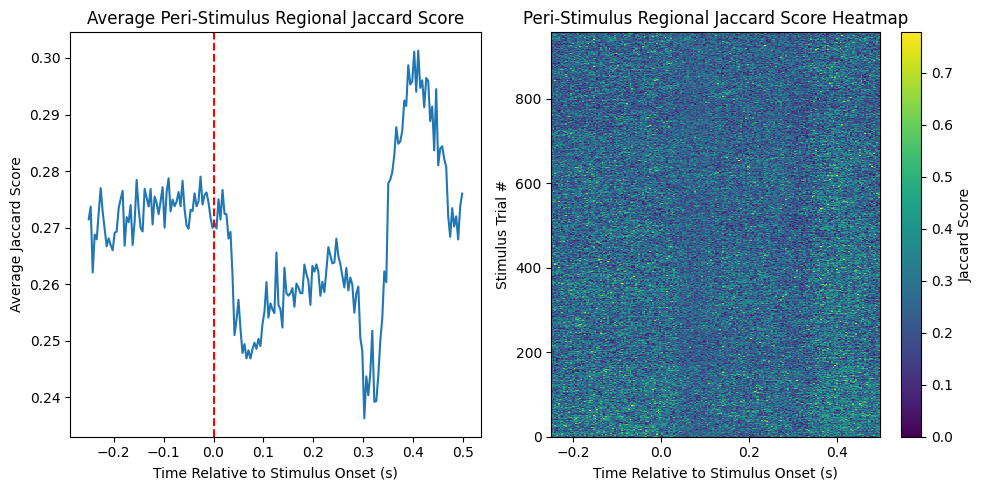

In [84]:
K = 20
baseline_win = [-.25, 0]
baseline_start_idx = np.argmin(np.abs(t - baseline_win[0]))
baseline_end_idx   = np.argmin(np.abs(t - baseline_win[1]))

# compute peri-stimulus rank 
peri_stim_rank = np.zeros((len(stim_st), n_bins_in_snippet,n_neurons))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    peri_stim_rank[i,:,:] = rank_matrix[start_idx : start_idx + n_bins_in_snippet]

baseline_ranks = peri_stim_rank[:,baseline_start_idx:baseline_end_idx, :]
avg_rank_per_neuron = np.mean(np.mean(baseline_ranks, axis=0), axis=0)

baseline_top_K_indices = np.argsort(avg_rank_per_neuron)[:K]

S_Baseline = set(baseline_top_K_indices)
C_Baseline_regions = set(locs[baseline_top_K_indices])

jaccard_scores_baseline_ref          = np.zeros(n_timepoints)
jaccard_scores_baseline_ref_regional = np.zeros(n_timepoints)

for t_idx in range(n_timepoints):
    # A. Get the instantaneous influential set S_t
    # Find indices where the rank is Top K (rank_matrix <= K)
    indices_t = np.where(rank_matrix[t_idx, :] <= K)[0]
    regions_t_array = locs[indices_t]   
    
    S_t = set(indices_t)
    C_t = set(regions_t_array)
    # B. Calculate Intersection and Union
    intersection = len(S_t.intersection(S_Baseline))
    union = len(S_t.union(S_Baseline))
   
    intersection_regions = len(C_t.intersection(C_Baseline_regions))
    union_regions = len(C_t.union(C_Baseline_regions))    
    
    # C. Calculate Jaccard Similarity (Intersection / Union)
    if union > 0:
        jaccard_scores_baseline_ref[t_idx] = intersection / union
    else:
        jaccard_scores_baseline_ref[t_idx] = 0
        
    if union_regions > 0:
        jaccard_scores_baseline_ref_regional[t_idx] = intersection_regions / union_regions
    else:
        jaccard_scores_baseline_ref_regional[t_idx] = 0     

# --- 4. Visualization ---

jaccard_ref_snippets         = np.zeros((len(stim_st), n_bins_in_snippet))
jaccard_snippets_ref_regions = np.zeros((len(stim_st), n_bins_in_snippet))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    jaccard_ref_snippets[i, :]         = jaccard_scores_baseline_ref[start_idx : start_idx + n_bins_in_snippet]
    jaccard_snippets_ref_regions[i, :] = jaccard_scores_baseline_ref_regional[start_idx : start_idx + n_bins_in_snippet]


fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_ref_snippets, axis=0))
ax[0].set_title('Average Peri-Stimulus Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_ref_snippets, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets_ref_regions, axis=0))
ax[0].set_title('Average Peri-Stimulus Regional Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets_ref_regions, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Regional Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()